# Wyniki: ktora kara za sklad dziala lepiej

Porownanie E1 i E2. Obie kary licza sie PER SEKWENCJA i obie maja wage 1,0, wiec jedyna roznica
miedzy nimi to **KSZTALT kary** — architektura, dane, podzial, energia i parowania sa identyczne.
Pelny opis: [../EKSPERYMENTY.md](../EKSPERYMENTY.md).

```
E1   kara TV        odleglosc od celu naturalnego   DWUSTRONNA: karze takze nadmiar
E2   kara progowa   progi DOLNE udzialow            JEDNOSTRONNA: nadmiar bezkarny
```

## Miary

```
identycznosc_nt    ile pozycji ma te sama ZASADE co wzorzec        ROZSTRZYGA
identycznosc_par   to samo, ale para liczy sie po TYPIE            ROZSTRZYGA
                   G-C i C-G to trafienie w G:C; z definicji >= identycznosc_nt,
                   a roznica miedzy nimi to bledy samej orientacji
dE/nt              o ile stabilizujemy cel lepiej niz wzorzec      kontrola
perplexity         z ilu zasad model srednio wybiera               kontrola
kara_wlasna        czy kara zadzialala                             diagnostyka
```

Rozstrzygaja identycznosci, bo sa zewnetrzne wobec obu kar. `kara_wlasna` to **inna wielkosc
w E1 i w E2** — tych liczb nie wolno zestawiac ze soba. Kara E1 nie schodzi do zera nawet dla
sekwencji naturalnych: na zbiorze treningowym maja one TV srednio 0,249.

**Kubelki NARASTAJACE:** `<= 100 nt` zawiera takze struktury krotsze niz 50 nt.

Kary w tabeli liczone sa na WYGENEROWANYCH sekwencjach, a w treningu na rozkladach
prawdopodobienstwa — te liczby nie zgadzaja sie z logiem i nie jest to blad.

In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.dataset import motyw_pozycji, parse_pairs, BASES, MOTYWY
from src.prepare import wczytaj, wczytaj_eterna
from src.split import wczytaj_split

# --- wspolny styl wykresow -------------------------------------------------
# Paleta sprawdzona pod katem separacji przy protanopii i deuteranopii oraz kontrastu wobec tla.
C1, C2, C3, C4 = "#0E6B60", "#9C5518", "#6B4E9C", "#8A9896"
INK, INK2, SIATKA = "#14201E", "#4C5C59", "#DCE4E2"
plt.rcParams["figure.dpi"] = 120

# Kubelki NARASTAJACE: "<= 100 nt" zawiera w sobie "<= 50 nt".
KUBELKI = [50, 100, 200]


def styl(ax, tytul="", ylab="", xlab=""):
    """Wspolne ustawienia osi: bez ramki, siatka pozioma, stonowane opisy."""
    ax.set_facecolor("none")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SIATKA)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.grid(axis="y", color=SIATKA, lw=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    if tytul:
        ax.set_title(tytul, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.set_xlabel(xlab, color=INK2, fontsize=9)


def sklad_motywy(structs, seqs):
    """Zliczenia A/C/G/U w kazdym motywie strukturalnym, po wszystkich sekwencjach."""
    c = {m: Counter() for m in MOTYWY}
    for st, sq in zip(structs, seqs):
        for m, b in zip(motyw_pozycji(st), sq):
            if m:
                c[m][b] += 1
    return c


def typy_par(structs, seqs):
    """Zliczenia typow par G:C / A:U / G:U."""
    t = Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(structs, seqs):
        for i, j in parse_pairs(st):
            p = sq[i] + sq[j]
            for k, g in grupy.items():
                if p in g:
                    t[k] += 1
    return t


In [2]:
ANALIZA = Path.cwd().parent / "experiments" / "analysis"
PLIKI = {
    "baseline losowy": "baseline_test.csv",
    "E1  kara TV":     "e1_test.csv",
    "E2  kara progowa": "e2_test.csv",
}

kawalki = []
for lab, p in PLIKI.items():
    f = ANALIZA / p
    if f.exists():
        x = pd.read_csv(f)
        x["etykieta"] = lab
        kawalki.append(x)
    else:
        print(f"brak {p} — uruchom odpowiedni eksperyment")

if kawalki:
    d = pd.concat(kawalki, ignore_index=True)
    display(d[["etykieta", "kara", "zbior", "dlugosc", "n",
               "identycznosc_nt", "identycznosc_par", "dE_nt", "kara_wlasna", "perplexity"]])
else:
    d = pd.DataFrame()
    print("brak wynikow — najpierw `python run.py E1` i `python run.py E2`")

,etykieta,kara,zbior,dlugosc,n,identycznosc_nt,identycznosc_par,dE_nt,kara_wlasna,perplexity
0,baseline losowy,brak kary za sklad,test,<= 50 nt,14,23.439641,49.360986,0.046466,NaN,NaN
1,baseline losowy,brak kary za sklad,test,<= 100 nt,458,26.208301,41.596438,-0.061587,NaN,NaN
2,baseline losowy,brak kary za sklad,test,<= 200 nt,728,26.250354,41.516182,-0.053077,NaN,NaN
3,baseline losowy,brak kary za sklad,eterna,<= 50 nt,12,33.298744,52.357291,0.125940,NaN,NaN
4,baseline losowy,brak kary za sklad,eterna,<= 100 nt,22,33.950465,53.098519,0.140231,NaN,NaN
5,baseline losowy,brak kary za sklad,eterna,<= 200 nt,39,32.937615,53.433750,0.139350,NaN,NaN
6,E1 kara TV,kara TV (nasza),test,<= 50 nt,14,30.918439,60.223943,-0.256623,1.060193,4.617651
7,E1 kara TV,kara TV (nasza),test,<= 100 nt,458,28.923127,47.168742,-0.319883,1.046437,4.617651
8,E1 kara TV,kara TV (nasza),test,<= 200 nt,728,29.408233,48.199431,-0.300017,1.039307,4.617651
9,E1 kara TV,kara TV (nasza),eterna,<= 50 nt,12,56.688129,73.595673,-0.150836,1.077000,4.617651


## 1. Identycznosc sekwencyjna — to rozstrzyga

Dwa slupki na model: identycznosc po zasadach i po typach par. **Roznica miedzy nimi to bledy samej
orientacji pary** — model wie, ze ma byc G:C, ale myli kierunek.

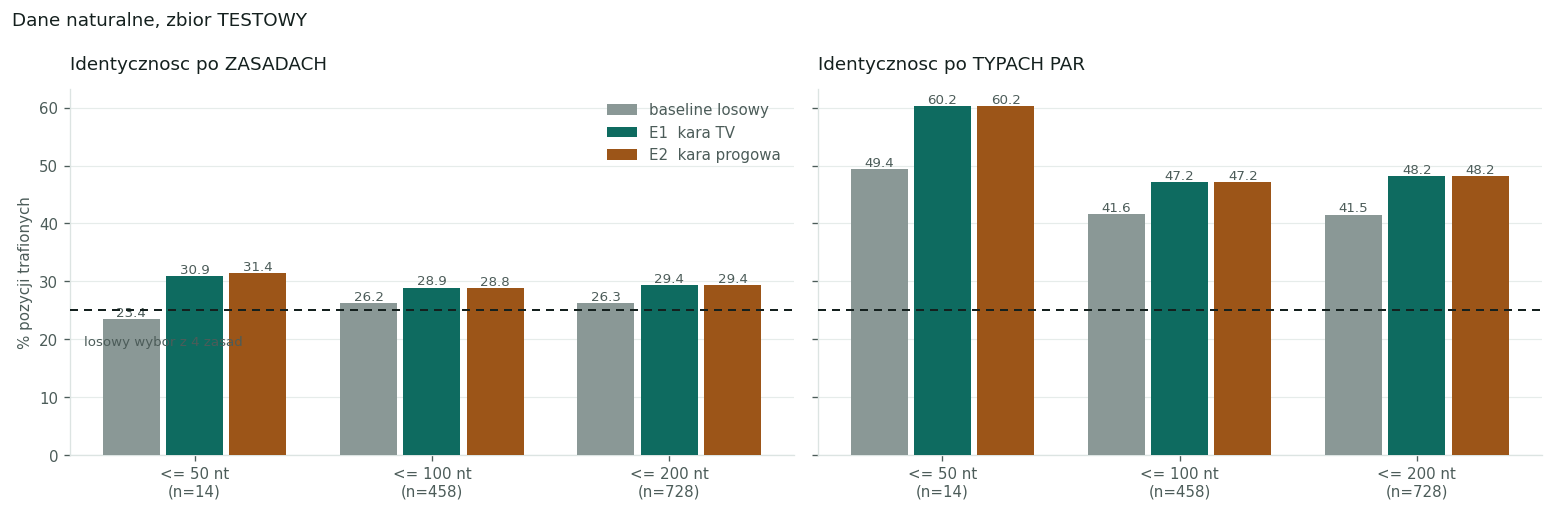

In [3]:
nat = d[d.zbior == "test"]
lab = list(dict.fromkeys(d.etykieta))
kolory_m = dict(zip(lab, [C4, C1, C2, C3][:len(lab)]))
kub = list(dict.fromkeys(nat.dlugosc))

fig, axs = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
x = np.arange(len(kub))
w = 0.8 / len(lab)
for ax, kol_nazwa, tyt in ((axs[0], "identycznosc_nt", "Identycznosc po ZASADACH"),
                           (axs[1], "identycznosc_par", "Identycznosc po TYPACH PAR")):
    for k, l in enumerate(lab):
        v = []
        for kk in kub:
            r = nat[(nat.etykieta == l) & (nat.dlugosc == kk)]
            v.append(float(r[kol_nazwa].iloc[0]) if len(r) else np.nan)
        b = ax.bar(x + (k - (len(lab) - 1) / 2) * w, v, w * 0.9,
                   color=kolory_m[l], label=l, zorder=3)
        for r, vv in zip(b, v):
            if vv == vv:
                ax.text(r.get_x() + r.get_width() / 2, vv + 0.5, f"{vv:.1f}",
                        ha="center", fontsize=8, color=INK2)
    ax.axhline(25, color=INK, lw=1.2, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{kk}\n(n={int(nat[nat.dlugosc == kk].n.iloc[0])})" for kk in kub],
                       fontsize=9)
    styl(ax, tyt, "% pozycji trafionych" if ax is axs[0] else "")
axs[0].text(0.02, 0.30, "losowy wybor z 4 zasad", transform=axs[0].transAxes,
            fontsize=8, color=INK2)
axs[0].legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.suptitle("Dane naturalne, zbior TESTOWY", color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 2. Energia — kontrola przy rownych warunkach

Czlon energetyczny ma w E1 i E2 identyczna wage, wiec zaden model nie ma tu przewagi. Ujemna wartosc
znaczy, ze nasza sekwencja stabilizuje zadana strukture LEPIEJ niz sekwencja wzorcowa.

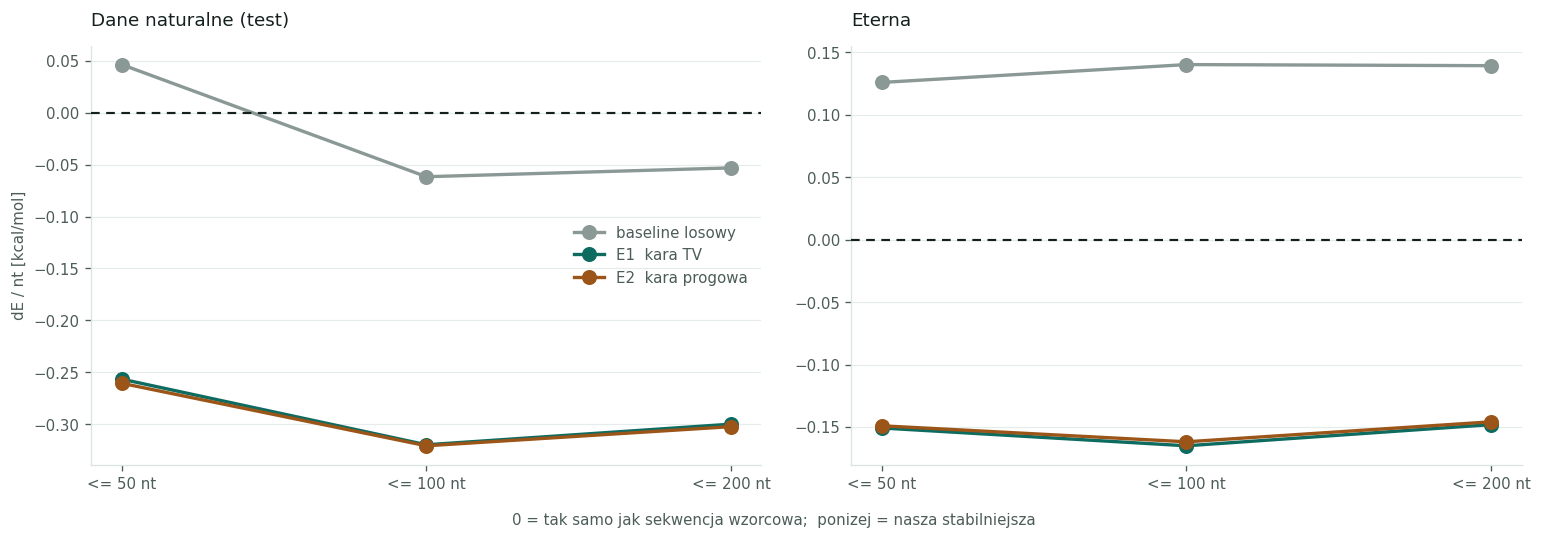

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, zb, tyt in ((axs[0], "test", "Dane naturalne (test)"),
                    (axs[1], "eterna", "Eterna")):
    czesc = d[d.zbior == zb]
    kk_lista = list(dict.fromkeys(czesc.dlugosc))
    for l in lab:
        v = []
        for kk in kk_lista:
            r = czesc[(czesc.etykieta == l) & (czesc.dlugosc == kk)]
            v.append(float(r.dE_nt.iloc[0]) if len(r) else np.nan)
        ax.plot(range(len(kk_lista)), v, "-o", color=kolory_m[l], lw=2, ms=8, label=l, zorder=3)
    ax.axhline(0, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(range(len(kk_lista)))
    ax.set_xticklabels(kk_lista, fontsize=9)
    styl(ax, tyt, "dE / nt [kcal/mol]" if ax is axs[0] else "")
axs[0].legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.text(0.5, -0.03, "0 = tak samo jak sekwencja wzorcowa;  ponizej = nasza stabilniejsza",
         ha="center", fontsize=9, color=INK2)
fig.tight_layout()

## 3. Co model faktycznie produkuje

Sklad wygenerowanych sekwencji wobec prawdziwych. Tu widac, czy kara zrobila to, co obiecywala —
i czy nie doprowadzila do degeneracji. Wymaga GPU.

In [5]:
import torch
from src.evaluate import wczytaj_model, generuj, eterna as eterna_zbior

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baza = wczytaj()
idx = wczytaj_split("rodzinowy")["test"]
S = baza.secondary_structure.iloc[idx].tolist()
Q = baza.sequence.iloc[idx].tolist()

MODELE = {"E1  kara TV": "checkpoints/e1_sklad_tv.pt",
          "E2  kara progowa": "checkpoints/e2_sklad_progi.pt"}
gen = {}
for l, ck in MODELE.items():
    if (Path.cwd().parent / ck).exists():
        m, _ = wczytaj_model(ck, dev)
        gen[l] = generuj(m, S, dev)
        del m
        torch.cuda.empty_cache()
    else:
        print(f"brak {ck}")
print(f"wygenerowano dla {len(S)} struktur testowych")

c:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


wygenerowano dla 728 struktur testowych


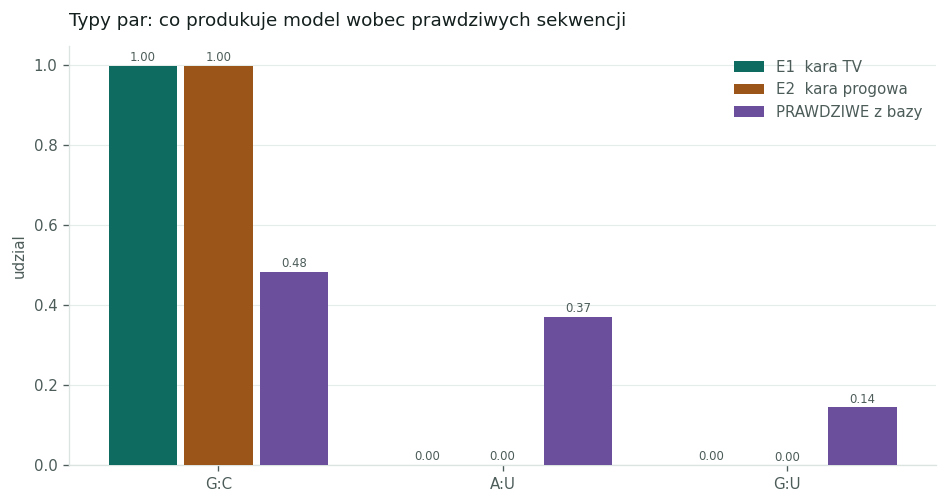

In [6]:
zrodla_m = list(gen.items()) + [("PRAWDZIWE z bazy", Q)]
kolory_z = [C1, C2, C3, C4]

fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(3)
w = 0.8 / len(zrodla_m)
for k, (l, g) in enumerate(zrodla_m):
    t = typy_par(S, g)
    tot = sum(t.values()) or 1
    v = [t[kk] / tot for kk in ("G:C", "A:U", "G:U")]
    b = ax.bar(x + (k - (len(zrodla_m) - 1) / 2) * w, v, w * 0.9,
               color=kolory_z[k], label=l, zorder=3)
    for r, vv in zip(b, v):
        ax.text(r.get_x() + r.get_width() / 2, vv + 0.012, f"{vv:.2f}",
                ha="center", fontsize=7, color=INK2)
ax.set_xticks(x)
ax.set_xticklabels(["G:C", "A:U", "G:U"], fontsize=10)
styl(ax, "Typy par: co produkuje model wobec prawdziwych sekwencji", "udzial")
ax.legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.tight_layout()

UDZIAL ADENINY w pozycjach niesparowanych

motyw                   pozycji        E1  kara TV   E2  kara progowa   PRAWDZIWE z bazy
spinka                     9376              0.962              0.953              0.286
wybrzuszenie              12636              0.957              0.965              0.313
multipetla                 1217              0.930              0.926              0.439
regiony-zewnetrzne         7322              0.988              0.990              0.311


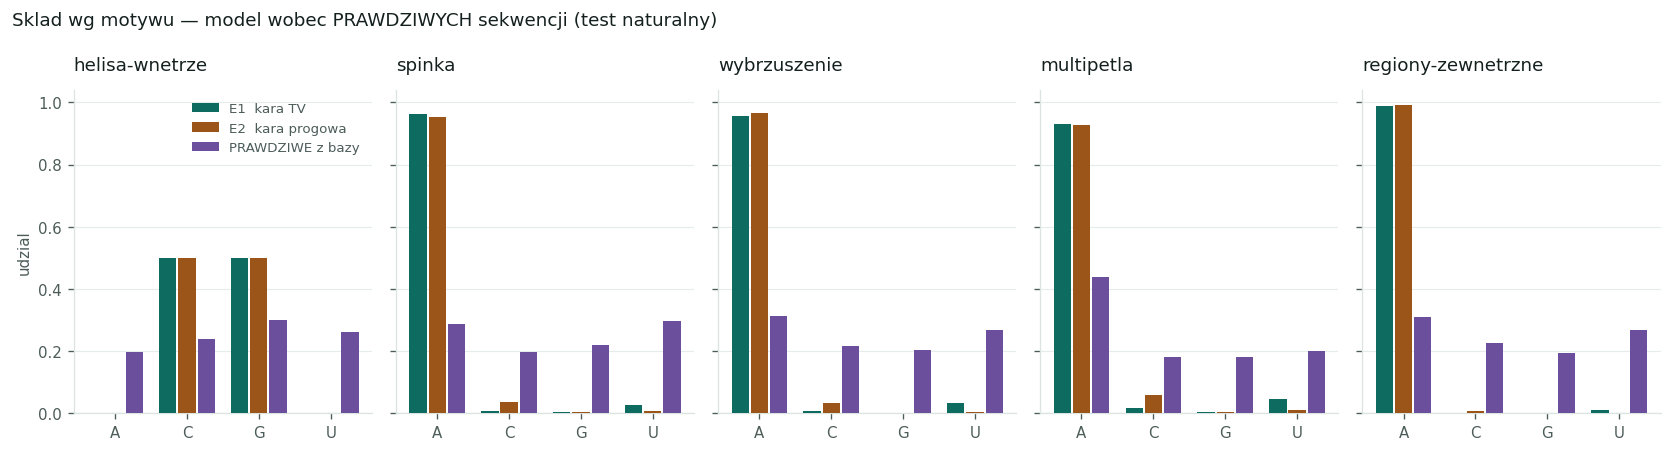

In [7]:
pokaz = ["helisa-wnetrze", "spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]

fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
x = np.arange(4)
w = 0.8 / len(zrodla_m)
for ax, m in zip(axs, pokaz):
    for k, (l, g) in enumerate(zrodla_m):
        c = sklad_motywy(S, g)[m]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla_m) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=kolory_z[k], label=l if m == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, m, "udzial" if m == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad wg motywu — model wobec PRAWDZIWYCH sekwencji (test naturalny)",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

# Udzial adeniny w pozycjach niesparowanych — tam degeneracja objawia sie najmocniej.
petle = ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]
print("UDZIAL ADENINY w pozycjach niesparowanych\n")
print(f"{'motyw':<22}{'pozycji':>9}" + "".join(f"{l:>19}" for l, _ in zrodla_m))
for mot in petle:
    n = sum(sklad_motywy(S, Q)[mot].values())
    kom = ""
    for l, g in zrodla_m:
        c = sklad_motywy(S, g)[mot]
        t = sum(c.values()) or 1
        kom += f"{c['A'] / t:>19.3f}"
    print(f"{mot:<22}{n:>9}" + kom)